In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## 1. Загрузка данных

Укажите папку, куда `generate_dataset.py` сохранил `.npy` файлы.

In [2]:
data_dir = Path("./data")

x0 = np.load(data_dir / "p0_samples.npy")
x1 = np.load(data_dir / "p1_samples.npy")

# Парная выборка (истинное EOT/SB-сопряжение) — опционально, если генерировали с --paired
paired_path0 = data_dir / "p0_paired.npy"
paired_path1 = data_dir / "p1_paired.npy"
has_paired = paired_path0.exists() and paired_path1.exists()

if has_paired:
    x0_paired = np.load(paired_path0)
    x1_paired = np.load(paired_path1)

print(f"x0: shape={x0.shape}, dtype={x0.dtype}, min={x0.min()}, max={x0.max()}")
print(f"x1: shape={x1.shape}, dtype={x1.dtype}, min={x1.min()}, max={x1.max()}")
print(f"Парная выборка найдена: {has_paired}")

x0: shape=(10000, 2), dtype=int64, min=0, max=49
x1: shape=(10000, 2), dtype=int64, min=4, max=46
Парная выборка найдена: True


## 2. Определяем параметры бенчмарка (D, S) по данным

In [3]:
D = x0.shape[1]
# число дискретных состояний по каждой координате (предполагаем одинаковое S для всех d)
S = int(max(x0.max(), x1.max()) + 1)

print(f"D (размерность) = {D}")
print(f"S (число состояний на координату) = {S}")

D (размерность) = 2
S (число состояний на координату) = 50


## 3. 2D-хитмапы p_0 и p_1 (для D=2)

Если D=2, каждую выборку удобно представить как 2D-гистограмму по дискретной решётке [0, S-1] x [0, S-1].

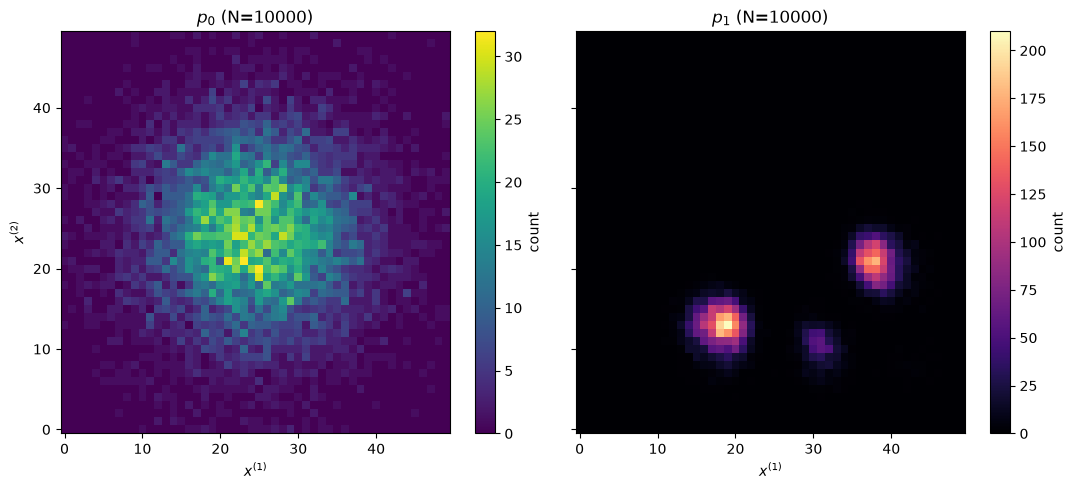

In [4]:
if D == 2:
    bins = np.arange(S + 1) - 0.5  # границы бинов так, чтобы каждое целое значение попадало в свой бин

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

    h0, _, _, im0 = axes[0].hist2d(x0[:, 0], x0[:, 1], bins=[bins, bins], cmap="viridis")
    axes[0].set_title(f"$p_0$ (N={len(x0)})")
    axes[0].set_xlabel("$x^{(1)}$")
    axes[0].set_ylabel("$x^{(2)}$")
    fig.colorbar(im0, ax=axes[0], label="count")

    h1, _, _, im1 = axes[1].hist2d(x1[:, 0], x1[:, 1], bins=[bins, bins], cmap="magma")
    axes[1].set_title(f"$p_1$ (N={len(x1)})")
    axes[1].set_xlabel("$x^{(1)}$")
    fig.colorbar(im1, ax=axes[1], label="count")

    plt.tight_layout()
    plt.show()
else:
    print(f"D={D} != 2, 2D-хитмап пропущен (см. маргинальные распределения ниже)")

## 4. Маргинальные распределения по каждой координате

Полезно, когда D > 2 или просто хочется посмотреть на распределение отдельно по каждой оси.

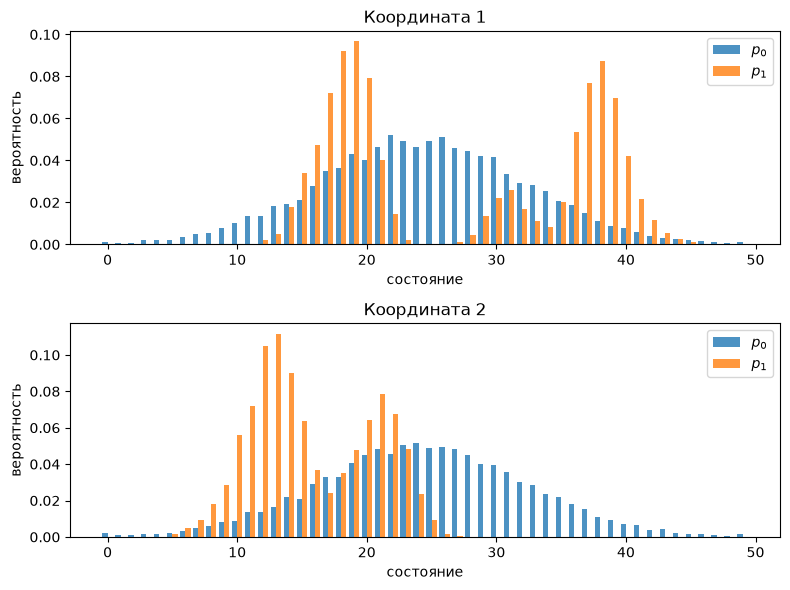

In [5]:
fig, axes = plt.subplots(D, 1, figsize=(8, 3 * D), squeeze=False)
states = np.arange(S)

for d in range(D):
    ax = axes[d, 0]
    counts0 = np.bincount(x0[:, d], minlength=S) / len(x0)
    counts1 = np.bincount(x1[:, d], minlength=S) / len(x1)

    width = 0.4
    ax.bar(states - width / 2, counts0, width=width, label="$p_0$", alpha=0.8)
    ax.bar(states + width / 2, counts1, width=width, label="$p_1$", alpha=0.8)
    ax.set_title(f"Координата {d + 1}")
    ax.set_xlabel("состояние")
    ax.set_ylabel("вероятность")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Визуализация парного сопряжения x0 -> x1 (если есть ground truth)

Показывает, куда конкретно "переезжают" точки под истинным EOT/SB-сопряжением p*(x1 | x0). Работает только для D=2 и только если генерировали датасет с `--paired`.

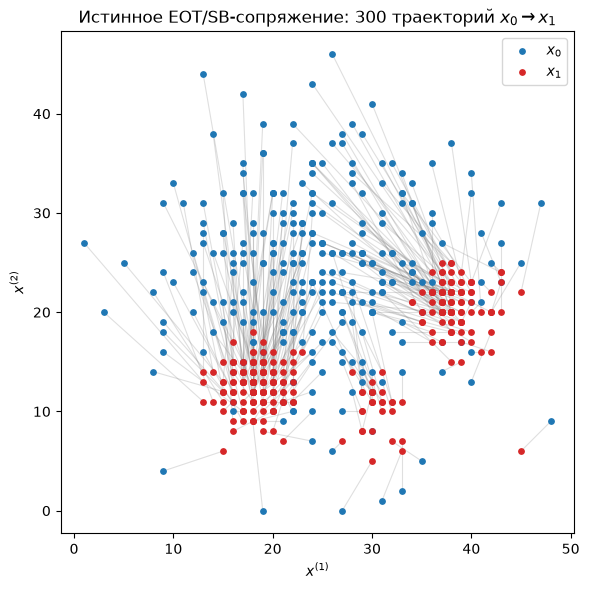

In [6]:
if has_paired and D == 2:
    n_show = min(300, len(x0_paired))  # рисуем не все точки, иначе график превращается в кашу
    idx = np.random.choice(len(x0_paired), size=n_show, replace=False)

    fig, ax = plt.subplots(figsize=(6, 6))

    for i in idx:
        ax.plot(
            [x0_paired[i, 0], x1_paired[i, 0]],
            [x0_paired[i, 1], x1_paired[i, 1]],
            color="gray", alpha=0.25, linewidth=0.8, zorder=1,
        )

    ax.scatter(x0_paired[idx, 0], x0_paired[idx, 1], color="tab:blue", label="$x_0$", s=15, zorder=2)
    ax.scatter(x1_paired[idx, 0], x1_paired[idx, 1], color="tab:red", label="$x_1$", s=15, zorder=2)

    ax.set_title(f"Истинное EOT/SB-сопряжение: {n_show} траекторий $x_0 \\to x_1$")
    ax.set_xlabel("$x^{(1)}$")
    ax.set_ylabel("$x^{(2)}$")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif not has_paired:
    print("Парная выборка не найдена — перегенерируйте датасет с флагом --paired, если нужен этот график")
else:
    print(f"D={D} != 2, визуализация сопряжения как линий пропущена")